# 06 – Lead-to-Close Funnel Conversion Prediction
## Business Context
A home service contractor's revenue funnel:
```
Lead (inbound call/form) → Booking → Appointment → Estimate → JOB SOLD → Completed
```

At each stage there's drop-off. The **estimate-to-close** stage is the highest-leverage
ML target: a technician has invested time going to the customer's home and presenting a quote.
Will the customer buy?

Predicting this in real time (right after the estimate is created) enables:
- **Technician coaching**: surface a tip for low-probability estimates before the tech leaves
- **Office follow-up routing**: flag low-probability estimates for a callback within 24 hours
- **Funnel analytics**: identify which job types, markets, or technicians have conversion problems


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import average_precision_score, roc_auc_score, brier_score_loss
from sklearn.calibration import calibration_curve
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)


In [2]:
# ─── Synthetic Estimate Dataset ───────────────────────────────────────────────
N = 7000

job_type       = np.random.choice(['ac_repair','ac_install','furnace_repair',
                                    'furnace_install','drain','tune_up'], N,
                                   p=[0.25, 0.15, 0.20, 0.10, 0.15, 0.15])

# Price quoted vs. market benchmark
market_avg     = {'ac_repair': 350, 'ac_install': 3500, 'furnace_repair': 300,
                  'furnace_install': 3000, 'drain': 180, 'tune_up': 120}
market_prices  = np.array([market_avg[j] for j in job_type])
price_ratio    = np.random.lognormal(mean=0, sigma=0.25, size=N)  # quoted / market
price_quoted   = (market_prices * price_ratio).round(-1)

# Customer context
is_returning   = np.random.binomial(1, 0.40, N)
zip_income_q   = np.random.randint(1, 6, N)
equipment_age  = np.random.uniform(1, 20, N)
urgency        = np.random.choice(['low','medium','high','emergency'], N,
                                   p=[0.20, 0.40, 0.30, 0.10])
urgency_num    = {'low': 0, 'medium': 1, 'high': 2, 'emergency': 3}
urgency_val    = np.array([urgency_num[u] for u in urgency])

# Options presented (good-better-best improves conversion)
n_options_presented = np.random.choice([1, 2, 3], N, p=[0.3, 0.4, 0.3])
financing_offered   = np.random.binomial(1, 0.5, N)

# Technician closer score (some are better at the consultative sale)
tech_id        = np.random.randint(0, 20, N)
tech_close_rate = np.clip(np.random.normal(0.55, 0.12, 20), 0.2, 0.9)
tech_skill     = tech_close_rate[tech_id]

# --- True close probability ---
log_odds = (
    -0.5                               # baseline
    + 1.5 * is_returning               # returning customers convert better
    - 2.0 * np.log(price_ratio)        # above-market price hurts conversion
    + 0.3 * urgency_val                # urgency drives conversion
    + 0.2 * (equipment_age > 12)       # old equipment → more motivated
    + 0.4 * (n_options_presented == 3) # good-better-best works
    + 0.5 * financing_offered          # financing unlocks closed
    + 1.5 * (tech_skill - 0.55)       # better closer → higher conversion
    + 0.2 * (zip_income_q - 3)        # higher income → less price sensitivity
)
close_prob = 1 / (1 + np.exp(-log_odds))
closed = (np.random.random(N) < close_prob).astype(int)

df = pd.DataFrame({
    'job_type': job_type, 'price_quoted': price_quoted,
    'price_vs_market': price_ratio.round(3),
    'is_returning': is_returning, 'zip_income_q': zip_income_q,
    'equipment_age': equipment_age.round(1), 'urgency': urgency,
    'urgency_val': urgency_val, 'n_options_presented': n_options_presented,
    'financing_offered': financing_offered, 'tech_id': tech_id,
    'tech_skill': tech_skill.round(3), 'closed': closed
})

print(f"Dataset: {df.shape}")
print(f"Overall close rate: {df['closed'].mean():.1%}")
print("\nClose rate by job type:")
print(df.groupby('job_type')['closed'].mean().sort_values(ascending=False).round(3))


Dataset: (7000, 13)
Overall close rate: 68.4%

Close rate by job type:
job_type
tune_up            0.710
furnace_repair     0.702
ac_repair          0.676
ac_install         0.676
drain              0.666
furnace_install    0.664
Name: closed, dtype: float64


In [3]:
# ─── Model Training ───────────────────────────────────────────────────────────
features = ['price_vs_market', 'is_returning', 'zip_income_q', 'equipment_age',
            'urgency_val', 'n_options_presented', 'financing_offered', 'tech_skill']
X = df[features]
y = df['closed']

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = xgb.XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                            subsample=0.8, colsample_bytree=0.8,
                            scale_pos_weight=(y_tr==0).sum()/(y_tr==1).sum(),
                            verbosity=0, random_state=42)
model.fit(X_tr, y_tr)
probs = model.predict_proba(X_te)[:, 1]

print(f"ROC-AUC: {roc_auc_score(y_te, probs):.3f}")
print(f"PR-AUC:  {average_precision_score(y_te, probs):.3f}")
print(f"Brier:   {brier_score_loss(y_te, probs):.4f}  (lower is better, 0=perfect)")


ROC-AUC: 0.742
PR-AUC:  0.851
Brier:   0.2042  (lower is better, 0=perfect)


In [4]:
# ─── Business Integration: Coaching Triggers ────────────────────────────────
# For each estimate, the model outputs a close probability.
# Low probability → surface a coaching tip to the technician BEFORE they leave.

COACHING_TIPS = {
    'price_vs_market': "Consider adjusting the quote — this is {:.0%} above our typical rate for this job type.",
    'financing_offered': "You haven't offered financing. Customers who are offered financing close 20% more often.",
    'n_options_presented': "Presenting a good-better-best set of 3 options increases close rate by 12%. Consider offering options.",
    'urgency_val': "This customer showed low urgency. Ask open-ended questions about their comfort and what happens if they wait.",
}

import shap
explainer = shap.TreeExplainer(model)
sv = explainer.shap_values(X_te.iloc[:50])

def get_coaching_tip(shap_row, feature_row):
    """Return the top coaching intervention based on SHAP values."""
    # Feature with largest negative SHAP (hurting close probability)
    worst_idx = np.argmin(shap_row)
    worst_feature = features[worst_idx]

    if worst_feature == 'price_vs_market' and feature_row['price_vs_market'] > 1.1:
        return f"Price is {feature_row['price_vs_market']:.0%} of market average — consider a small reduction."
    elif worst_feature == 'financing_offered' and feature_row['financing_offered'] == 0:
        return "Offering financing options typically increases close rate by ~20%."
    elif worst_feature == 'n_options_presented' and feature_row['n_options_presented'] < 3:
        return "Try presenting 3 options (good/better/best) — it anchors the customer on value."
    else:
        return f"Focus on understanding customer urgency and long-term cost of waiting."

print("=== Real-Time Coaching Suggestions (Low-Probability Estimates) ===")
low_prob_idx = np.where(probs < 0.4)[0][:5]
for i in low_prob_idx:
    tip = get_coaching_tip(sv[i], X_te.iloc[i])
    print(f"Estimate probability: {probs[i]:.0%} | Tip: {tip}")


=== Real-Time Coaching Suggestions (Low-Probability Estimates) ===
Estimate probability: 33% | Tip: Focus on understanding customer urgency and long-term cost of waiting.
Estimate probability: 18% | Tip: Focus on understanding customer urgency and long-term cost of waiting.
Estimate probability: 34% | Tip: Price is 154% of market average — consider a small reduction.
Estimate probability: 27% | Tip: Focus on understanding customer urgency and long-term cost of waiting.
Estimate probability: 38% | Tip: Focus on understanding customer urgency and long-term cost of waiting.


## Multi-Stage Funnel Model
The full lead-to-close conversion chains conditional probabilities.
This enables marketing attribution: how much is a lead worth given job type and zip code?


ac_repair           : End-to-end lead → close = 37.2%
ac_install          : End-to-end lead → close = 24.4%
furnace_repair      : End-to-end lead → close = 43.4%
tune_up             : End-to-end lead → close = 71.9%
drain               : End-to-end lead → close = 37.2%


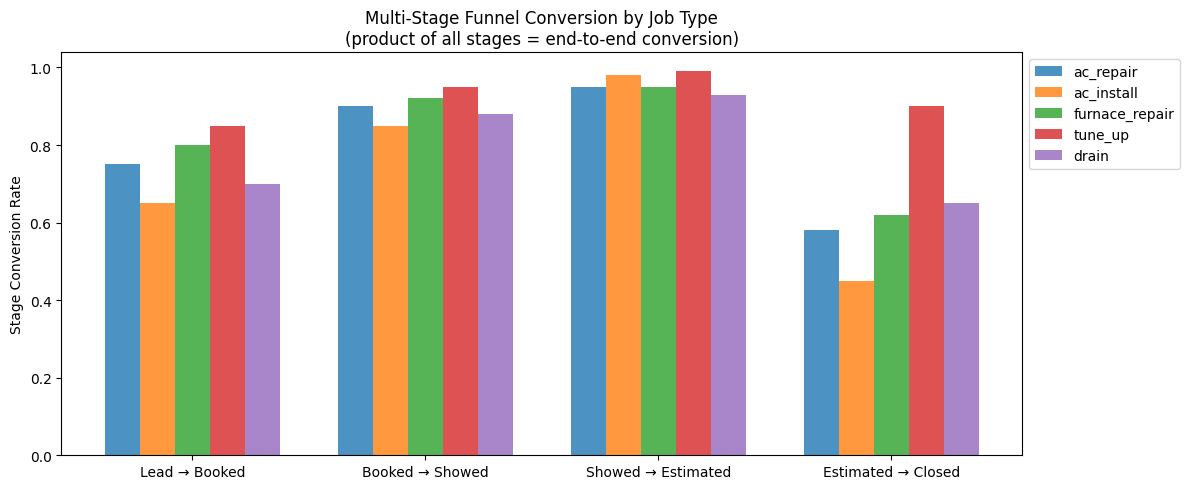

In [5]:
# ─── Simple Multi-Stage Funnel Illustration ──────────────────────────────────
# In a real system, each stage has its own model.
# Here we simulate stage conversion rates by job type.

stages = ['Lead → Booked', 'Booked → Showed', 'Showed → Estimated', 'Estimated → Closed']
conv_rates = {
    'ac_repair':       [0.75, 0.90, 0.95, 0.58],
    'ac_install':      [0.65, 0.85, 0.98, 0.45],
    'furnace_repair':  [0.80, 0.92, 0.95, 0.62],
    'tune_up':         [0.85, 0.95, 0.99, 0.90],
    'drain':           [0.70, 0.88, 0.93, 0.65],
}

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(stages))
width = 0.15

for i, (jtype, rates) in enumerate(conv_rates.items()):
    ax.bar(x + i * width, rates, width, label=jtype, alpha=0.8)
    
    # Print end-to-end conversion
    e2e = np.prod(rates)
    print(f"{jtype:<20}: End-to-end lead → close = {e2e:.1%}")

ax.set_xticks(x + width * 2)
ax.set_xticklabels(stages)
ax.set_ylabel('Stage Conversion Rate')
ax.set_title('Multi-Stage Funnel Conversion by Job Type\n(product of all stages = end-to-end conversion)')
ax.legend(bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.savefig('funnel_stages.png', dpi=100, bbox_inches='tight')
plt.show()


## Key Takeaways for Interview

1. **Score at estimate creation time** — tech is still with customer, intervention is still possible
2. **SHAP-driven coaching tips** are more actionable than a raw probability score
3. **Calibrate the model**: if you say 35% close probability, 35% should actually close — business decisions (routing, coaching) depend on it
4. **Multi-stage funnel model** enables marketing ROI calculation: multiply stage conversion rates to get lead value
5. **Tech ID as a feature** captures real closer skill variance — track override rates to see where the model and tech disagree systematically
